# EDA - Geological and Surficial Datasets

In [14]:
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [94]:
##### CHANGE DIRECTORIES #####
#shpgeo_dir = Path("/Path/to/the/shpgeo/directory")
#fsa_path = Path("/Path/to/fsa/boundary/dataset/gfsa000a11a_e.shp")
#radon_path = Path("/Path/to/cross-Canada/radon/survey/dataset/radon-concentration.csv")
shpgeo_dir = Path("/Users/huiyaokuang/OneDrive/Erdos Institute/radon project/data/Geological map of Canada/as_1860a/as_1860/CANADA/SHPGEO/geology_fsa_radon.csv")
fsa_path = Path("/Users/huiyaokuang/OneDrive/Erdos Institute/radon project/data/FSA data/gfsa000a11a_e/gfsa000a11a_e.shp")
radon_path = Path("/Users/huiyaokuang/OneDrive/Erdos Institute/radon project/data/cross Canada radon survey/radon-concentration.csv")
surficial_path = Path("/Users/huiyaokuang/OneDrive/Erdos Institute/radon project/data/surficial geology/surficial_fsa_radon.csv")

## 1. Geological Map of Canada

In [8]:
geo = pd.read_csv(shpgeo_dir)

In [10]:
geo.columns

Index(['ProvinceTerritory', 'FSA', 'TestDurationInDays',
       'AverageRadonConcentrationInBqPerM3', 'RXTP_intrusive rocks',
       'RXTP_metamorphic rocks', 'RXTP_sedimentary and volcanic rocks',
       'RXTP_sedimentary rocks', 'RXTP_unknown', 'RXTP_volcanic rocks',
       'GEOLPROV_Appalachian Orogen', 'GEOLPROV_Arctic Continental Shelf',
       'GEOLPROV_Arctic Platform', 'GEOLPROV_Atlantic Continental Shelf',
       'GEOLPROV_Bear Province', 'GEOLPROV_Churchill Province',
       'GEOLPROV_Cordilleran Orogen', 'GEOLPROV_Grenville Province',
       'GEOLPROV_Hudson Bay Lowlands', 'GEOLPROV_Innuitian Orogen',
       'GEOLPROV_Interior Platform', 'GEOLPROV_Nain Province',
       'GEOLPROV_Pacific Continental Shelf', 'GEOLPROV_Slave Province',
       'GEOLPROV_Southern Province', 'GEOLPROV_St. Lawrence Platform',
       'GEOLPROV_Superior Province', 'GEOLPROV_Unknown',
       'GEOLPROV_oceanic crust'],
      dtype='str')

In [11]:
geo.info()

<class 'pandas.DataFrame'>
RangeIndex: 13567 entries, 0 to 13566
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ProvinceTerritory                    13567 non-null  str    
 1   FSA                                  13567 non-null  str    
 2   TestDurationInDays                   13567 non-null  float64
 3   AverageRadonConcentrationInBqPerM3   13567 non-null  float64
 4   RXTP_intrusive rocks                 13567 non-null  float64
 5   RXTP_metamorphic rocks               13567 non-null  float64
 6   RXTP_sedimentary and volcanic rocks  13567 non-null  float64
 7   RXTP_sedimentary rocks               13567 non-null  float64
 8   RXTP_unknown                         13567 non-null  float64
 9   RXTP_volcanic rocks                  13567 non-null  float64
 10  GEOLPROV_Appalachian Orogen          13567 non-null  float64
 11  GEOLPROV_Arctic Continental Shelf    13

### Radon data

<Axes: xlabel='AverageRadonConcentrationInBqPerM3', ylabel='Count'>

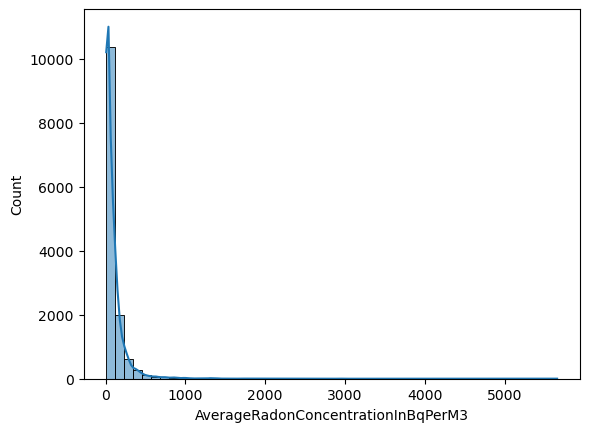

In [16]:
sns.histplot(geo["AverageRadonConcentrationInBqPerM3"], bins=50, kde=True)

<Axes: xlabel='AverageRadonConcentrationInBqPerM3', ylabel='Count'>

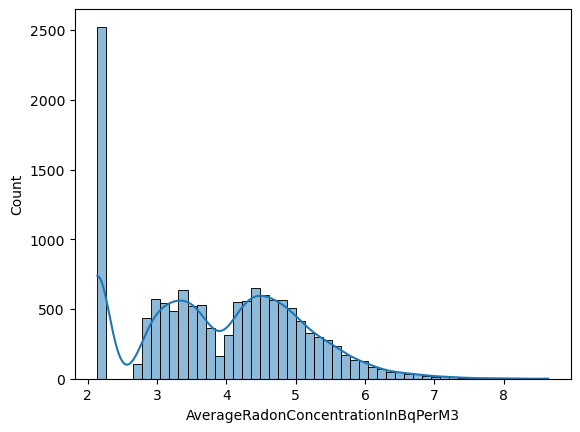

In [22]:
sns.histplot(np.log1p(geo["AverageRadonConcentrationInBqPerM3"]), bins=50, kde=True)

<Axes: xlabel='count', ylabel='ProvinceTerritory'>

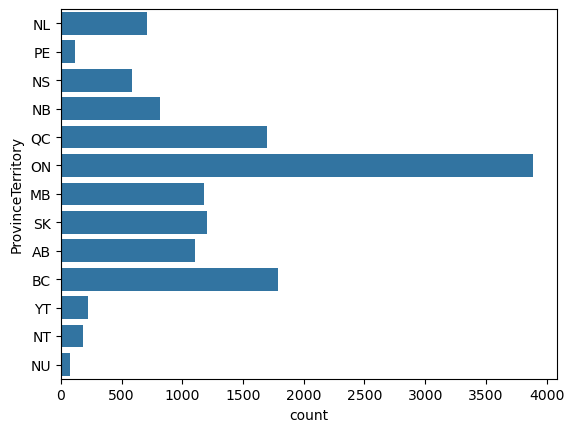

In [20]:
sns.countplot(geo["ProvinceTerritory"])

### RXTP (Rock Type)

##### (a) Survey-level

Survey-level analyses are used to understand the modeling target distribution.

array([[<Axes: title={'center': 'RXTP_intrusive rocks'}>,
        <Axes: title={'center': 'RXTP_metamorphic rocks'}>],
       [<Axes: title={'center': 'RXTP_sedimentary and volcanic rocks'}>,
        <Axes: title={'center': 'RXTP_sedimentary rocks'}>],
       [<Axes: title={'center': 'RXTP_unknown'}>,
        <Axes: title={'center': 'RXTP_volcanic rocks'}>]], dtype=object)

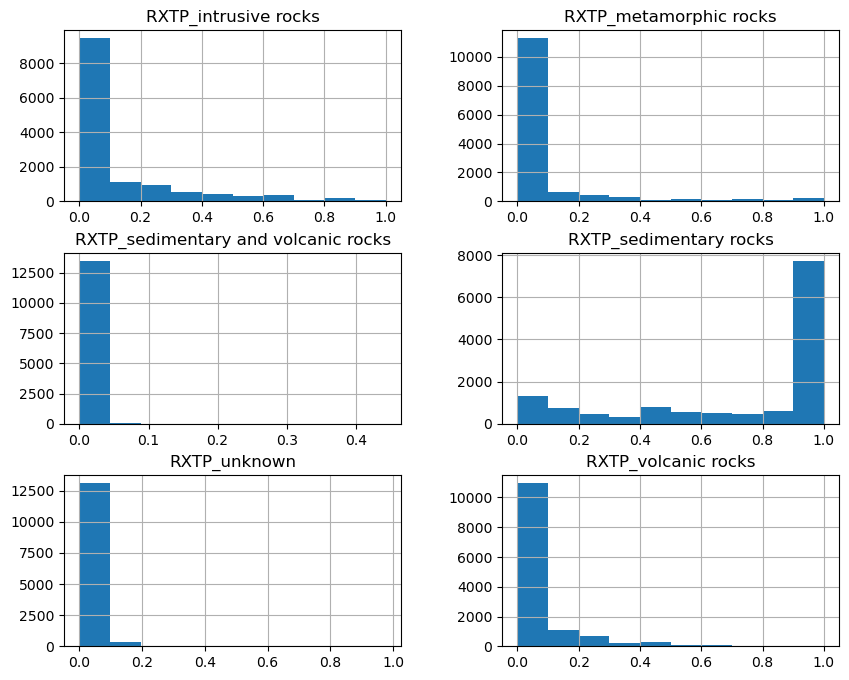

In [24]:
# RXTP distribution
rxtp_cols = [c for c in geo.columns if c.startswith("RXTP_")]
geo[rxtp_cols].describe()
geo[rxtp_cols].hist(figsize=(10,8))

In [25]:
geo[rxtp_cols].sum(axis=1).describe()

count    1.356700e+04
mean     1.000000e+00
std      1.292457e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [27]:
row_max = geo[rxtp_cols].max(axis=1)
row_max.describe()

count    13567.000000
mean         0.840746
std          0.207597
min          0.333703
25%          0.663502
50%          0.994620
75%          1.000000
max          1.000000
dtype: float64

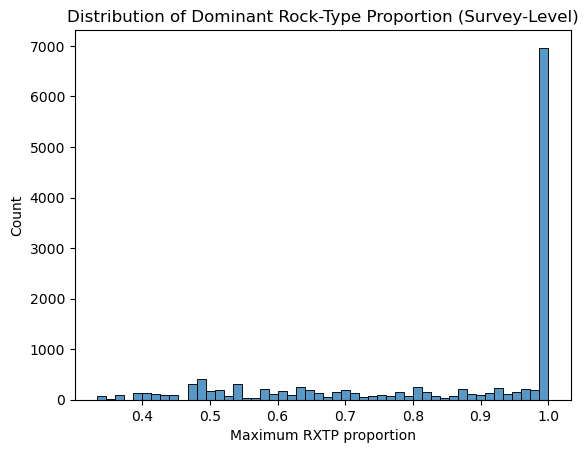

In [51]:
sns.histplot(row_max, bins=50)
plt.title("Distribution of Dominant Rock-Type Proportion (Survey-Level)")
plt.xlabel("Maximum RXTP proportion")
plt.show()

row_max shows:

The majority of FSAs are nearly single-rock-type regions.

The median maximum RXTP proportion is 0.995.

75% of FSAs are fully dominated by one rock type.

##### (b) FSA-level

FSA-level analyses to understand the geological feature structures.

In [46]:
geo_fsa = geo.drop_duplicates("FSA")
geo_fsa.shape

(1014, 29)

array([[<Axes: title={'center': 'RXTP_intrusive rocks'}>,
        <Axes: title={'center': 'RXTP_metamorphic rocks'}>],
       [<Axes: title={'center': 'RXTP_sedimentary and volcanic rocks'}>,
        <Axes: title={'center': 'RXTP_sedimentary rocks'}>],
       [<Axes: title={'center': 'RXTP_unknown'}>,
        <Axes: title={'center': 'RXTP_volcanic rocks'}>]], dtype=object)

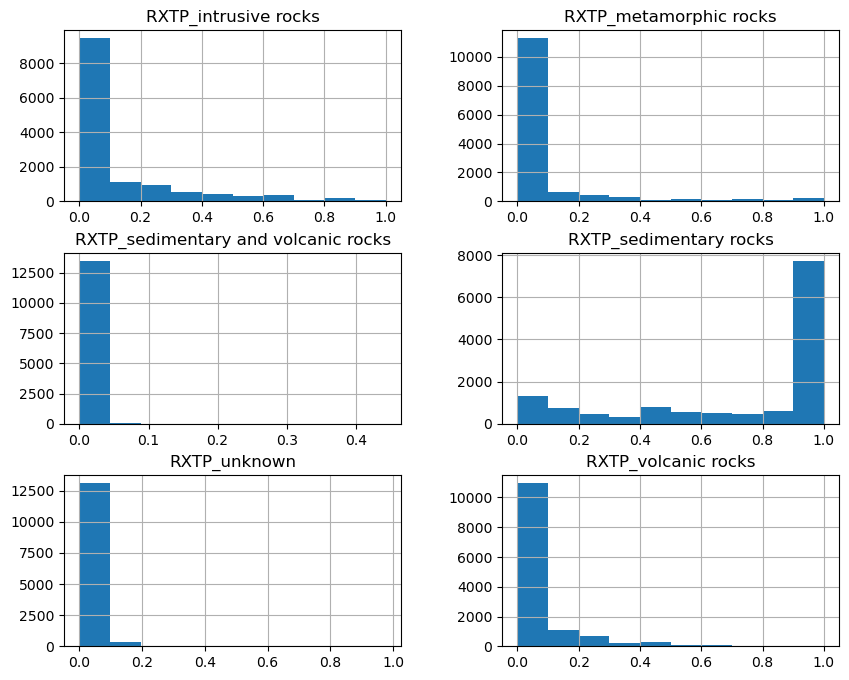

In [48]:
# RXTP distribution
rxtp_cols_fsa = [c for c in geo_fsa.columns if c.startswith("RXTP_")]
geo[rxtp_cols_fsa].describe()
geo[rxtp_cols_fsa].hist(figsize=(10,8))

In [50]:
row_max_fsa = geo_fsa[rxtp_cols_fsa].max(axis=1)
row_max_fsa.describe()

count    1014.000000
mean        0.899808
std         0.173837
min         0.333703
25%         0.855153
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64

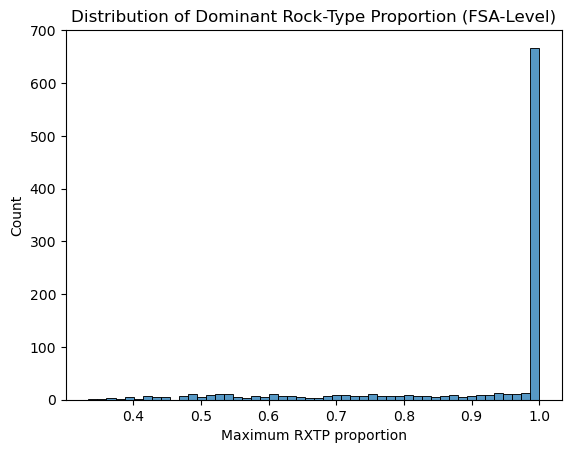

In [52]:
sns.histplot(row_max_fsa, bins=50)
plt.title("Distribution of Dominant Rock-Type Proportion (FSA-Level)")
plt.xlabel("Maximum RXTP proportion")
plt.show()

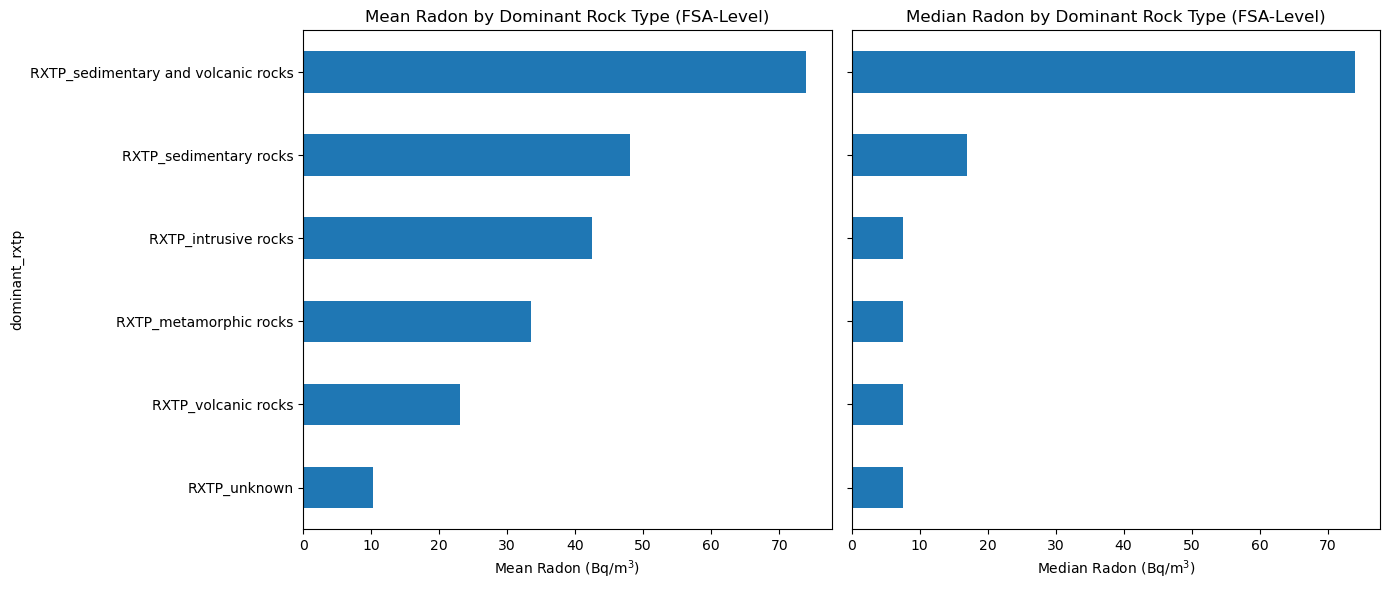

In [87]:
geo_fsa["dominant_rxtp"] = geo_fsa[rxtp_cols_fsa].idxmax(axis=1)

rk = geo_fsa.groupby("dominant_rxtp")["AverageRadonConcentrationInBqPerM3"]
mean_grouped = rk.mean()
median_grouped = rk.median()

order = mean_grouped.sort_values().index
mean_grouped = mean_grouped.loc[order]
median_grouped = median_grouped.loc[order]
    
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

mean_grouped.plot(kind="barh", ax=axes[0])
axes[0].set_xlabel("Mean Radon (Bq/m$^3$)")
axes[0].set_title("Mean Radon by Dominant Rock Type (FSA-Level)")

median_grouped.plot(kind="barh", ax=axes[1])
axes[1].set_xlabel("Median Radon (Bq/m$^3$)")
axes[1].set_title("Median Radon by Dominant Rock Type (FSA-Level)")

plt.tight_layout()
plt.show()

Many of the median radon values are 7.5 because measurements reported as "<15" were replaced with 7.5.

As a result, the median does not clearly distinguish between different rock types.

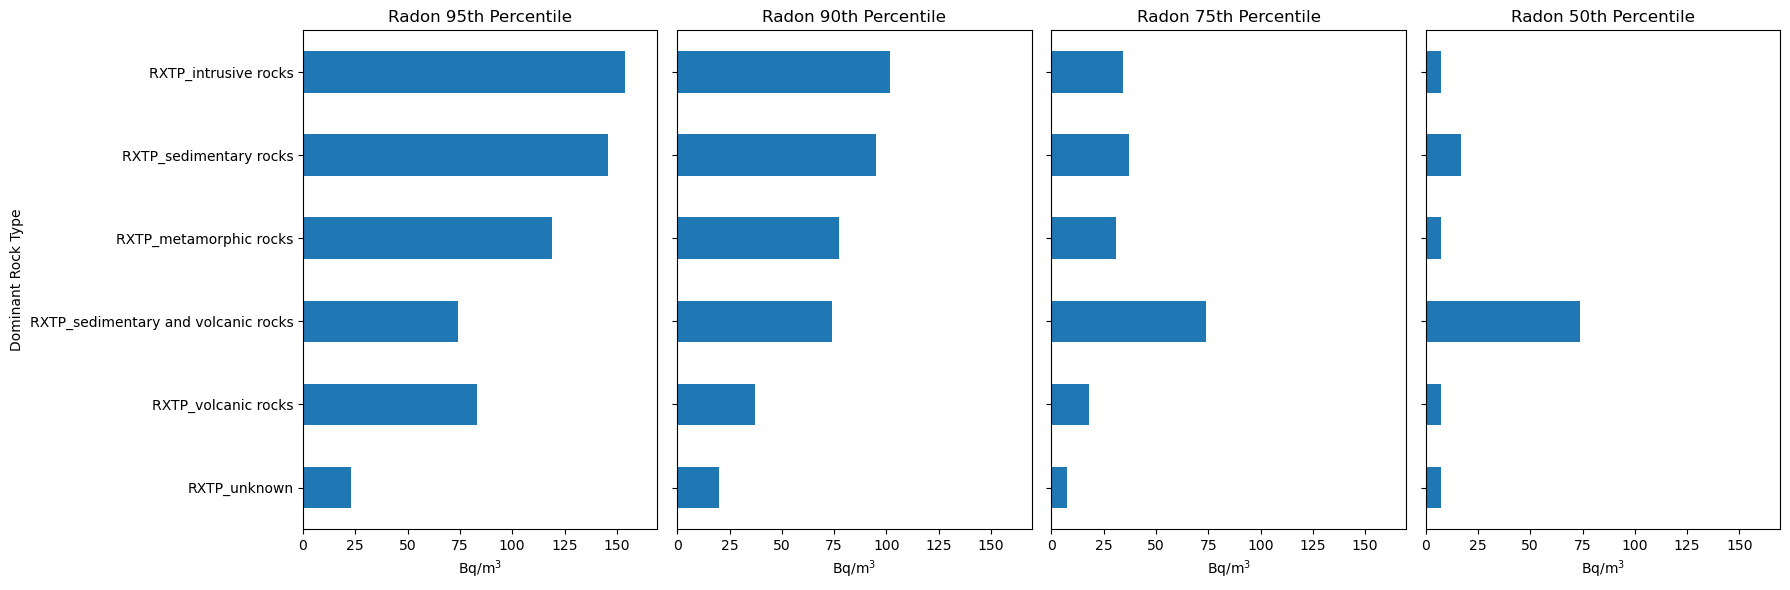

In [88]:
# Order by 0.9?
qs = [0.95, 0.90, 0.75, 0.50]

q_table = (
    geo_fsa.groupby("dominant_rxtp")["AverageRadonConcentrationInBqPerM3"]
    .quantile(qs)
    .unstack()   # columns = quantiles
)

order = q_table[0.9].sort_values().index  # or 0.95? 
q_table = q_table.loc[order]

q50_grouped = rk.quantile(0.50)
q75_grouped = rk.quantile(0.75)
q90_grouped = rk.quantile(0.90)
q95_grouped = rk.quantile(0.95)
max_val = max(q50_grouped.max(), q75_grouped.max(), q90_grouped.max(), q95_grouped.max() )

fig, axes = plt.subplots(1, len(qs), figsize=(18, 6), sharey=True)
for ax, q in zip(axes, qs):
    q_table[q].plot(kind="barh", ax=ax)
    ax.set_title(f"Radon {int(q*100)}th Percentile")
    ax.set_xlabel("Bq/m$^3$")

for ax in axes:
    ax.set_xlim(0, max_val*1.1)
    
axes[0].set_ylabel("Dominant Rock Type")
plt.tight_layout()
plt.show()

### GEOLPROV (Geological Province)

##### (a) Survey-level

In [38]:
# GEOLPROV distribution
geop_cols = [c for c in geo.columns if c.startswith("GEOLPROV_")]
geo[geop_cols].sum(axis=1).describe()

count    1.356700e+04
mean     1.000000e+00
std      8.417900e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

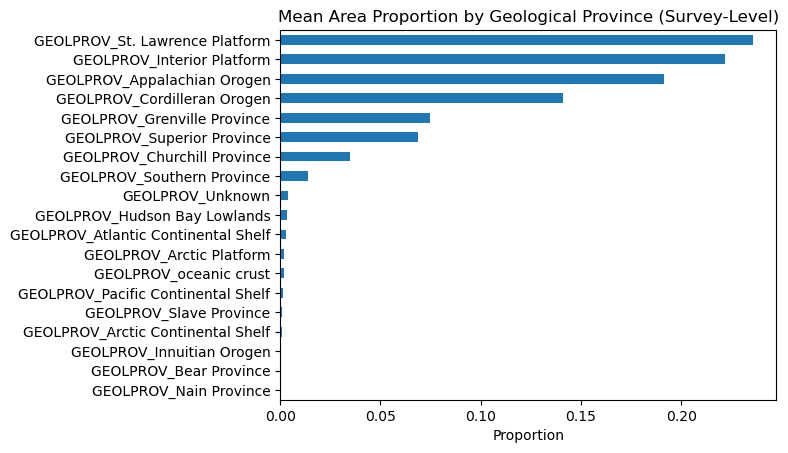

In [55]:
geo[geop_cols].mean().sort_values().plot(kind="barh")
plt.title("Mean Area Proportion by Geological Province (Survey-Level)")
plt.xlabel("Proportion")
plt.show()


##### (b) FSA-level

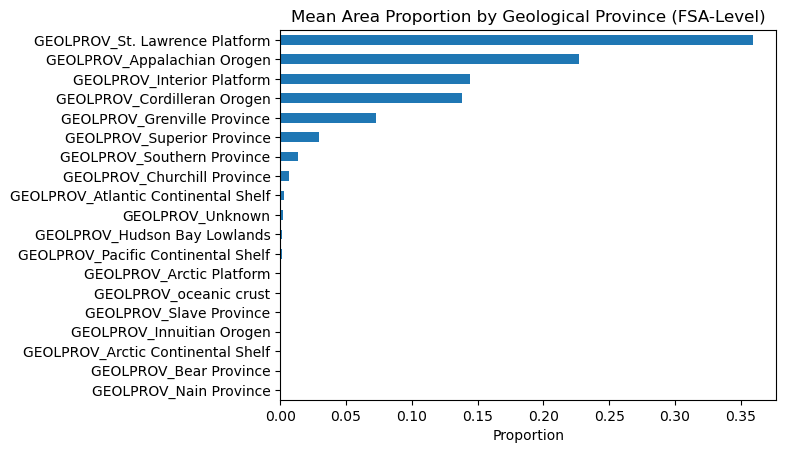

In [56]:
geo_fsa[geop_cols].mean()
geo_fsa[geop_cols].mean().sort_values().plot(kind="barh")
plt.title("Mean Area Proportion by Geological Province (FSA-Level)")
plt.xlabel("Proportion")
plt.show()

<Axes: ylabel='dominant_geoprov'>

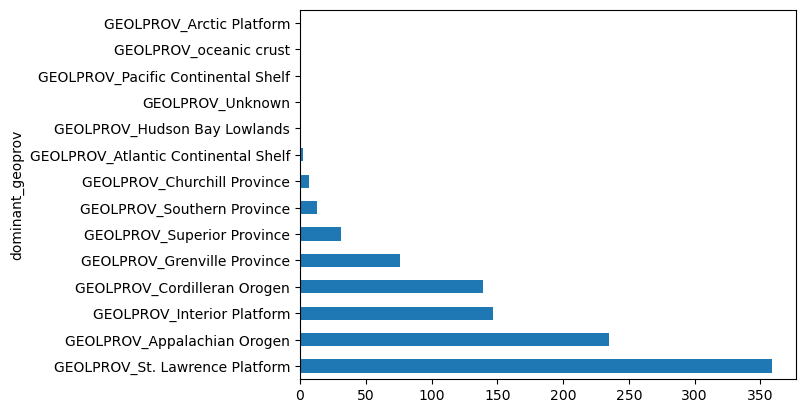

In [57]:
geo_fsa["dominant_geoprov"] = geo_fsa[geop_cols].idxmax(axis=1)
geo_fsa["dominant_geoprov"].value_counts().plot(kind="barh")

<Axes: ylabel='Count'>

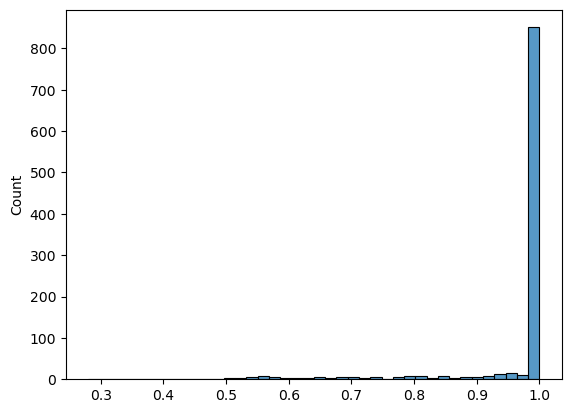

In [58]:
row_max = geo_fsa[geop_cols].max(axis=1)
sns.histplot(row_max, bins=40)

Most FSAs belong to single geological province.

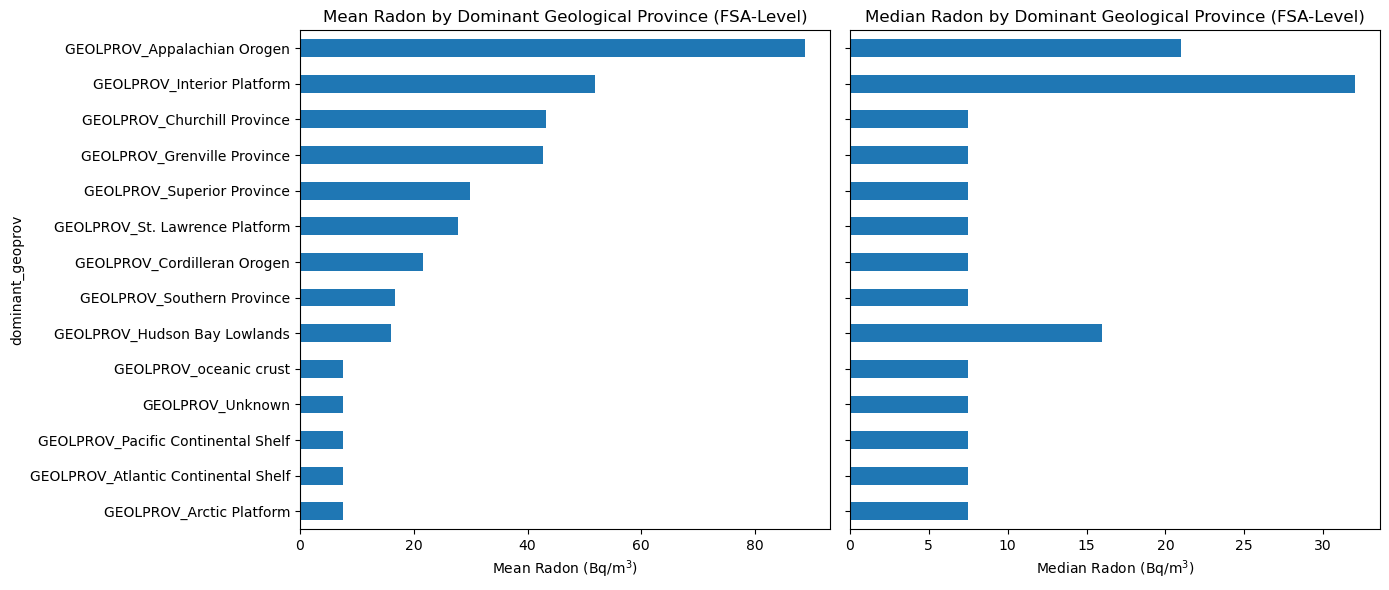

In [71]:
g = geo_fsa.groupby("dominant_geoprov")["AverageRadonConcentrationInBqPerM3"]
mean_grouped = g.mean()
median_grouped = g.median()

order = mean_grouped.sort_values().index
mean_grouped = mean_grouped.loc[order]
median_grouped = median_grouped.loc[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

mean_grouped.plot(kind="barh", ax=axes[0])
axes[0].set_xlabel("Mean Radon (Bq/m$^3$)")
axes[0].set_title("Mean Radon by Dominant Geological Province (FSA-Level)")

median_grouped.plot(kind="barh", ax=axes[1])
axes[1].set_xlabel("Median Radon (Bq/m$^3$)")
axes[1].set_title("Median Radon by Dominant Geological Province (FSA-Level)")

plt.tight_layout()
plt.show()

Many of the median radon values are 7.5 because measurements reported as "<15" were replaced with 7.5.

As a result, the median does not clearly distinguish between different rock types.

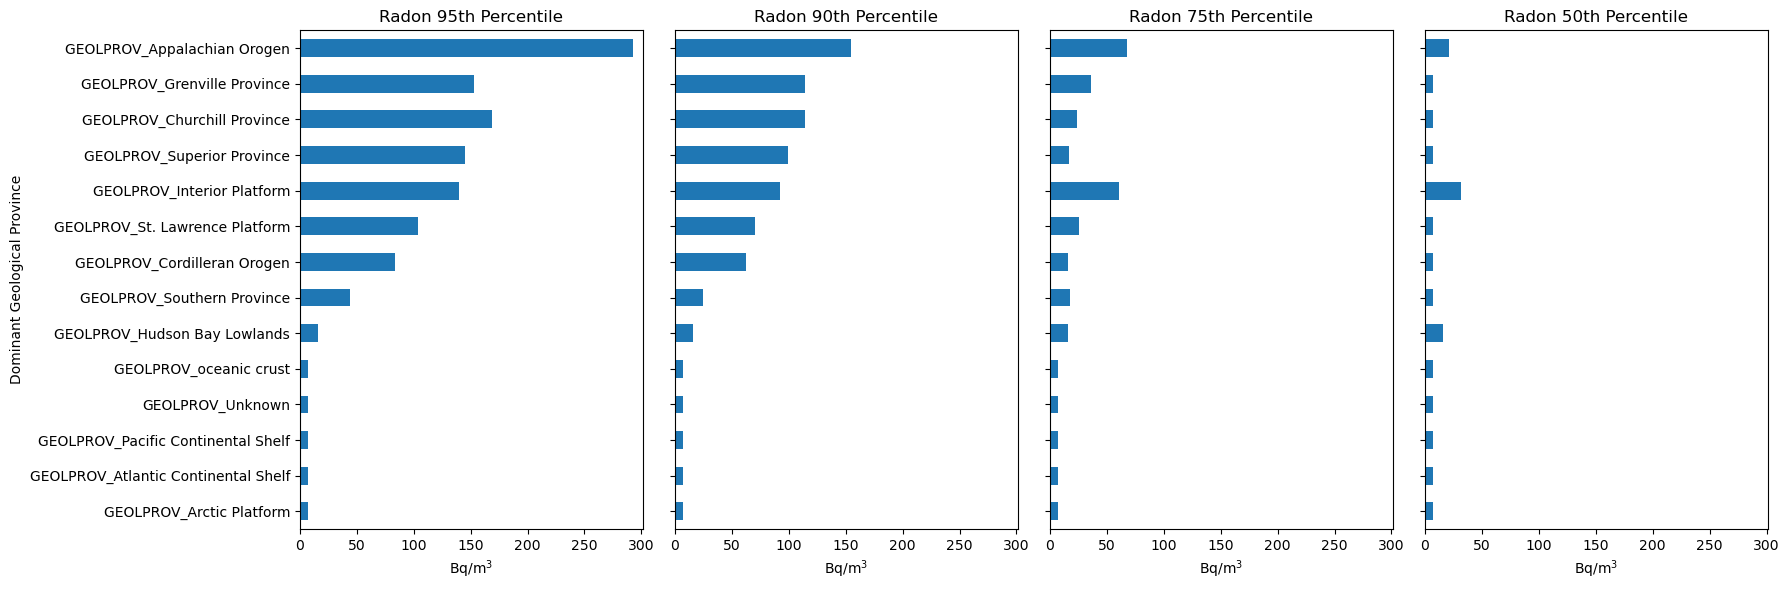

In [93]:
# Order by 0.9?
qs = [0.95, 0.90, 0.75, 0.50]

q_table = (
    geo_fsa.groupby("dominant_geoprov")["AverageRadonConcentrationInBqPerM3"]
    .quantile(qs)
    .unstack()   # columns = quantiles
)

q50_grouped = g.quantile(0.50)
q75_grouped = g.quantile(0.75)
q90_grouped = g.quantile(0.90)
q95_grouped = g.quantile(0.95)
max_val = max(q50_grouped.max(), q75_grouped.max(), q90_grouped.max(), q95_grouped.max() )

order = q_table[0.9].sort_values().index  # or 0.95? - both orders look similar
q_table = q_table.loc[order]

fig, axes = plt.subplots(1, len(qs), figsize=(18, 6), sharey=True)
for ax, q in zip(axes, qs):
    q_table[q].plot(kind="barh", ax=ax)
    ax.set_title(f"Radon {int(q*100)}th Percentile")
    ax.set_xlabel("Bq/m$^3$")

for ax in axes:
    ax.set_xlim(0, max_val*1.03)
    
axes[0].set_ylabel("Dominant Geological Province")
plt.tight_layout()
plt.show()

In [77]:
geo_fsa["dominant_geoprov"].value_counts()

dominant_geoprov
GEOLPROV_St. Lawrence Platform         359
GEOLPROV_Appalachian Orogen            235
GEOLPROV_Interior Platform             147
GEOLPROV_Cordilleran Orogen            139
GEOLPROV_Grenville Province             76
GEOLPROV_Superior Province              31
GEOLPROV_Southern Province              13
GEOLPROV_Churchill Province              7
GEOLPROV_Atlantic Continental Shelf      2
GEOLPROV_Hudson Bay Lowlands             1
GEOLPROV_Unknown                         1
GEOLPROV_Pacific Continental Shelf       1
GEOLPROV_oceanic crust                   1
GEOLPROV_Arctic Platform                 1
Name: count, dtype: int64

# 2. Surficial Geology Dataset

In [97]:
surf = pd.read_csv(surficial_path)
surf.info()

<class 'pandas.DataFrame'>
RangeIndex: 13567 entries, 0 to 13566
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   FSA                                  13567 non-null  str    
 1   Alluvial sediments                   13567 non-null  float64
 2   Bedrock                              13567 non-null  float64
 3   Colluvial and mass-wasting deposits  13567 non-null  float64
 4   Eolian sediments                     13567 non-null  float64
 5   Glacial Ice or Snowpack              13567 non-null  float64
 6   Glacial sediments                    13567 non-null  float64
 7   Glaciofluvial sediments              13567 non-null  float64
 8   Glaciolacustrine sediments           13567 non-null  float64
 9   Glaciomarine sediments               13567 non-null  float64
 10  Lacustrine sediments                 13567 non-null  float64
 11  Marine sediments                     13

##### (a) Survey-level

<Axes: ylabel='dominant_sedi'>

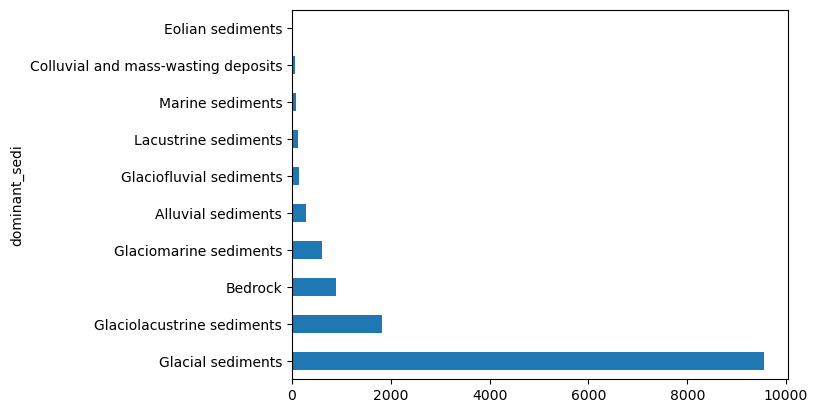

In [99]:
# Sediment distribution
sedi_cols = [c for c in surf.columns 
             if c not in ["FSA", "ProvinceTerritory"] and c not in ["TestDurationInDays","AverageRadonConcentrationInBqPerM3"]]
surf["dominant_sedi"] = surf[sedi_cols].idxmax(axis=1)
surf["dominant_sedi"].value_counts().plot(kind="barh")

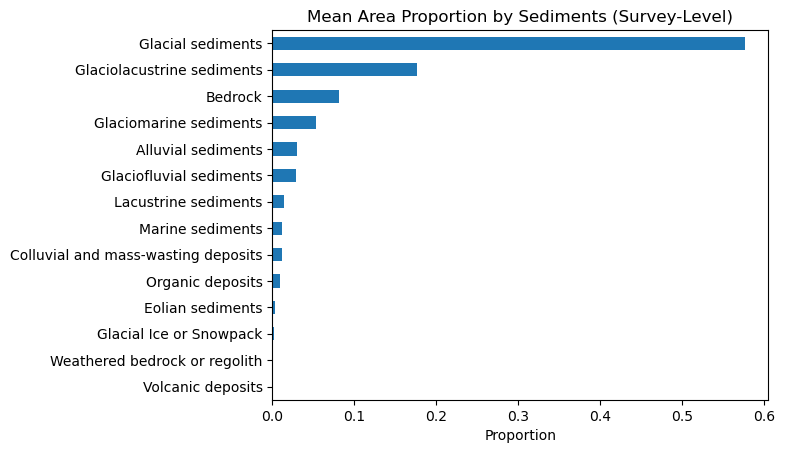

In [103]:
surf[sedi_cols].mean().sort_values().plot(kind="barh")
plt.title("Mean Area Proportion by Sediments (Survey-Level)")
plt.xlabel("Proportion")
plt.show()

##### (b) FSA-level

In [104]:
surf_fsa = surf.drop_duplicates("FSA")
surf_fsa.shape

(1014, 19)

<Axes: ylabel='dominant_sedi'>

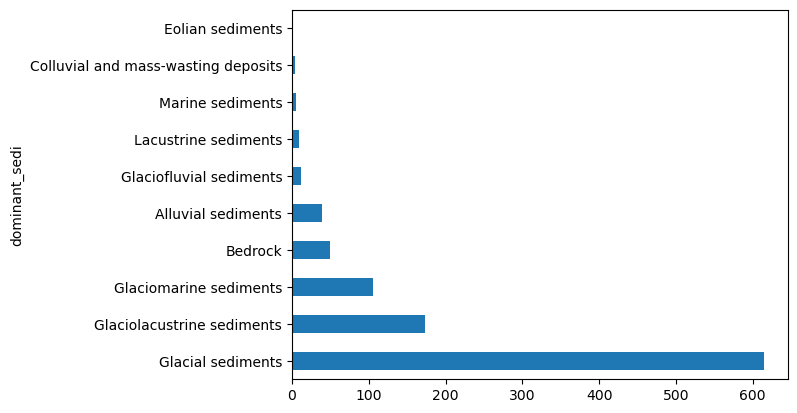

In [107]:
sedi_cols_fsa = [c for c in surf_fsa.columns 
             if c not in ["FSA", "ProvinceTerritory", "dominant_sedi"] and c not in ["TestDurationInDays","AverageRadonConcentrationInBqPerM3"]]
surf_fsa["dominant_sedi"] = surf_fsa[sedi_cols_fsa].idxmax(axis=1)
surf_fsa["dominant_sedi"].value_counts().plot(kind="barh")

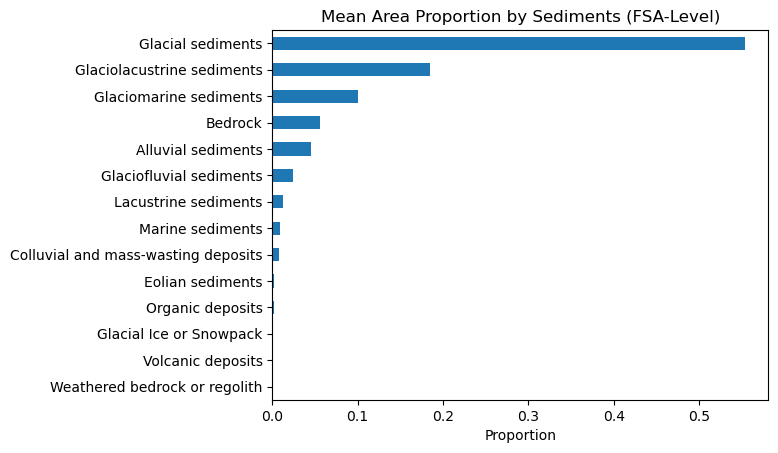

In [108]:
surf_fsa[sedi_cols_fsa].mean().sort_values().plot(kind="barh")
plt.title("Mean Area Proportion by Sediments (FSA-Level)")
plt.xlabel("Proportion")
plt.show()

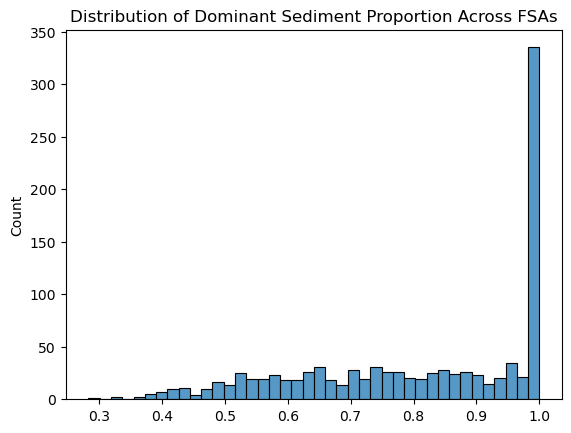

In [113]:
row_sedi_max = surf_fsa[sedi_cols_fsa].max(axis=1)
sns.histplot(row_sedi_max, bins=40)
plt.title("Distribution of Dominant Sediment Proportion Across FSAs")
plt.show()

Most FSAs are dominated by 1-2 sediment types. Most dominant sediments cover > 80% of the total area of FSA.

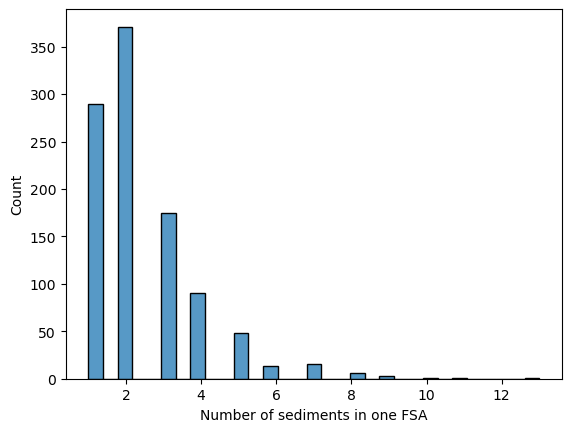

In [112]:
sns.histplot((surf_fsa[sedi_cols_fsa] > 0).sum(axis=1))
plt.xlabel("Number of sediments in one FSA")
plt.show()

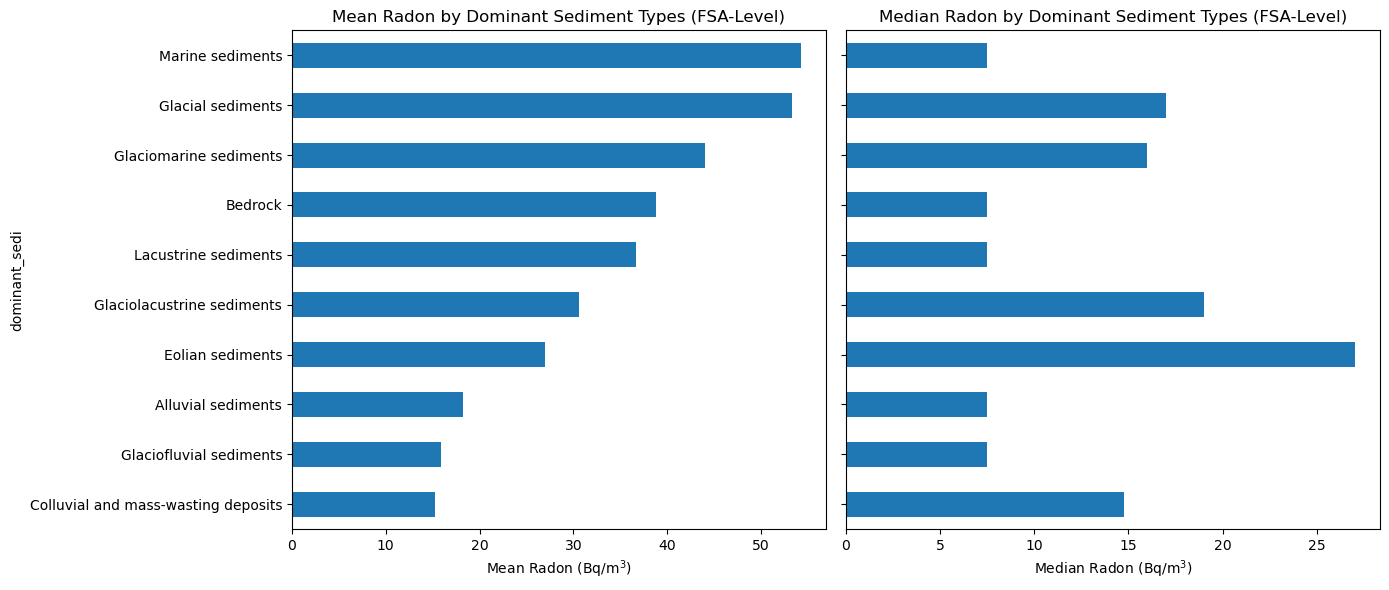

In [114]:
s = surf_fsa.groupby("dominant_sedi")["AverageRadonConcentrationInBqPerM3"]
mean_grouped = s.mean()
median_grouped = s.median()

order = mean_grouped.sort_values().index
mean_grouped = mean_grouped.loc[order]
median_grouped = median_grouped.loc[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

mean_grouped.plot(kind="barh", ax=axes[0])
axes[0].set_xlabel("Mean Radon (Bq/m$^3$)")
axes[0].set_title("Mean Radon by Dominant Sediment Types (FSA-Level)")

median_grouped.plot(kind="barh", ax=axes[1])
axes[1].set_xlabel("Median Radon (Bq/m$^3$)")
axes[1].set_title("Median Radon by Dominant Sediment Types (FSA-Level)")

plt.tight_layout()
plt.show()

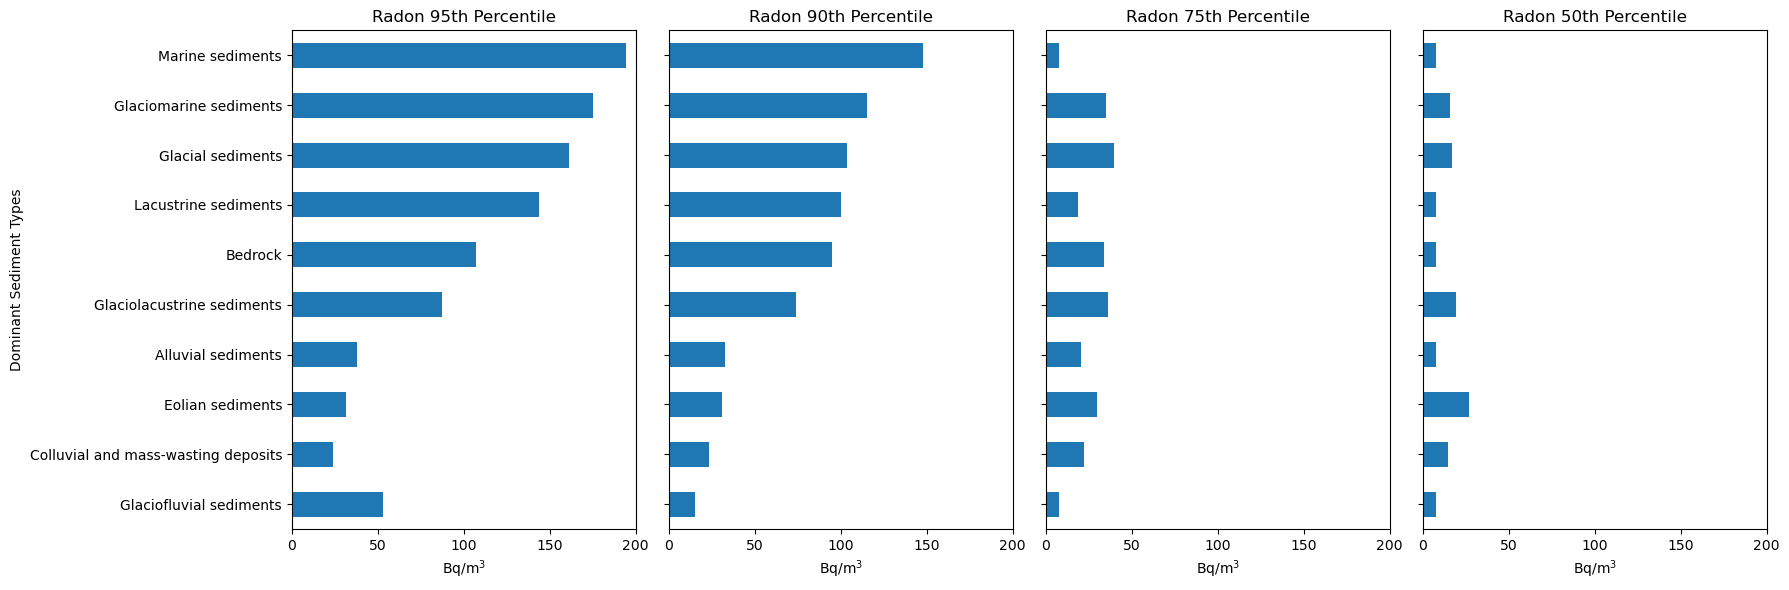

In [ ]:
# Order by 0.9?
qs = [0.95, 0.90, 0.75, 0.50]

q_table = (
    surf_fsa.groupby("dominant_sedi")["AverageRadonConcentrationInBqPerM3"]
    .quantile(qs)
    .unstack()   # columns = quantiles
)

q50_grouped = s.quantile(0.50)
q75_grouped = s.quantile(0.75)
q90_grouped = s.quantile(0.90)
q95_grouped = s.quantile(0.95)
max_val = max(q50_grouped.max(), q75_grouped.max(), q90_grouped.max(), q95_grouped.max() )

order = q_table[0.9].sort_values().index  # or 0.95?
q_table = q_table.loc[order]

fig, axes = plt.subplots(1, len(qs), figsize=(18, 6), sharey=True)
for ax, q in zip(axes, qs):
    q_table[q].plot(kind="barh", ax=ax)
    ax.set_title(f"Radon {int(q*100)}th Percentile")
    ax.set_xlabel("Bq/m$^3$")

for ax in axes:
    ax.set_xlim(0, max_val*1.03)
    
axes[0].set_ylabel("Dominant Sediment Types")
plt.tight_layout()
plt.show()